This notebook demonstrates usage examples the following modules/packages:
* Matplotlib and seaborn for plots
* Some NLTK module functions for text cleaning, splitting and lemmatisation
* Out-of-the-box (not fine-tuned) RoBERTa model for text vectorization
* LGBMRegressor model training on data folds
* Optuna for LGBMRegressor hyperparameters optimization

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from scipy.sparse import hstack, vstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import optuna
from transformers import RobertaTokenizer, TFRobertaModel

import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
from tensorflow.keras.optimizers.schedules import PolynomialDecay
from tensorflow.keras.optimizers import Adam

np.random.seed(42)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/roberta-large-model-tensorflow/config.json
/kaggle/input/roberta-large-model-tensorflow/merges.txt
/kaggle/input/roberta-large-model-tensorflow/README.md
/kaggle/input/roberta-large-model-tensorflow/tokenizer.json
/kaggle/input/roberta-large-model-tensorflow/vocab.json
/kaggle/input/roberta-large-model-tensorflow/tf_model.h5
/kaggle/input/commonlitreadabilityprize/sample_submission.csv
/kaggle/input/commonlitreadabilityprize/train.csv
/kaggle/input/commonlitreadabilityprize/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/commonlitreadabilityprize/train.csv", low_memory=False)
test = pd.read_csv("/kaggle/input/commonlitreadabilityprize/test.csv", low_memory=False)
train.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2834 non-null   object 
 1   url_legal       830 non-null    object 
 2   license         830 non-null    object 
 3   excerpt         2834 non-null   object 
 4   target          2834 non-null   float64
 5   standard_error  2834 non-null   float64
dtypes: float64(2), object(4)
memory usage: 3.8 MB


In [3]:
test.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         7 non-null      object
 1   url_legal  3 non-null      object
 2   license    3 non-null      object
 3   excerpt    7 non-null      object
dtypes: object(4)
memory usage: 8.2 KB


In [4]:
train.head()

,id,url_legal,license,excerpt,target,standard_error
0,c12129c31,NaN,NaN,When the young people returned to the ballroom...,-0.340259,0.464009
1,85aa80a4c,NaN,NaN,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805
2,b69ac6792,NaN,NaN,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676
3,dd1000b26,NaN,NaN,And outside before the palace a great garden w...,-1.054013,0.450007
4,37c1b32fb,NaN,NaN,Once upon a time there were Three Bears who li...,0.247197,0.510845


# **Data analysis**

In [5]:
train["target"].describe()

count    2834.000000
mean       -0.959319
std         1.033579
min        -3.676268
25%        -1.690320
50%        -0.912190
75%        -0.202540
max         1.711390
Name: target, dtype: float64

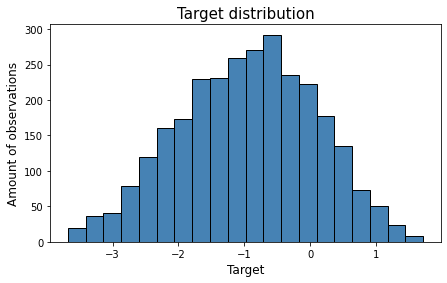

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train["target"], bins=20, edgecolor="black", color="steelblue")
ax.set_title("Target distribution", fontsize=15)
ax.set_xlabel("Target", fontsize=12)
ax.set_ylabel("Amount of observations", fontsize=12)
plt.show();

In [7]:
train["standard_error"].describe()

count    2834.000000
mean        0.491435
std         0.034818
min         0.000000
25%         0.468543
50%         0.484721
75%         0.506268
max         0.649671
Name: standard_error, dtype: float64

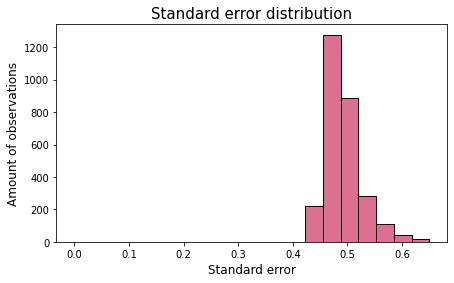

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train["standard_error"], bins=20, edgecolor="black", color="palevioletred")
ax.set_title("Standard error distribution", fontsize=15)
ax.set_xlabel("Standard error", fontsize=12)
ax.set_ylabel("Amount of observations", fontsize=12)
plt.show();

To make further analysis we need to exctract more data from text exceprts. So the function below calculates some numeric parameters I think may be important for target predicting like text length decrease after deleting stop words, mean sentence length, amount of quotes (i.e. dialogs), word and lemma mean length etc. The function returns only these parameters. The transformed and preprocessed text object is not returned.

In [9]:
def get_text_data_parameters(data, stop_words):
    """
    Calculates some numeric parameters of paragraphs of the given series object.
    """
    
    text_shortage = []
    quotes = []
    sentences = []
    sent_length = []
    word_length = []
    lemma_length = []
    
#     new_data = []
    for row in data:
        # Amount of quotes devided by 2 to determine if there is any dialogue
        quotes.append(row.count('"')/2)
        # The original, raw text paragraph lenght
        initial_length = len(row)
        # Using nltk tokenizer to split a text into sentences to determine their amount
        num_sent = len(sent_tokenize(row))
        sentences.append(num_sent)
        # Getting rid of all noncharacter symbols and splitting a text into 
        # words using nltk tokenizer and getting amount of words
        row = re.sub("[^a-zA-Z]", " ", row)
        row = row.lower()
        row = word_tokenize(row)
        num_words = len(row)
        
        # Calculating mean amount of words per sentence and mean word length 
        sent_length.append(num_words/num_sent)
        word_length.append(initial_length/num_words)
        # Splitting text data into words and dropping stop words
        row = [word for word in row if not word in stop_words]
        # Words lemmatisation
        lemma = nltk.WordNetLemmatizer()
        row = [lemma.lemmatize(word) for word in row]
        num_lemmas = len(row)
        row = " ".join(row)
        # Text length after cleaning and lemmatisation
        processed_length = len(row)
        # Calculating mean lemma length and amount of text shrinkage after the processing
        lemma_length.append(processed_length/num_lemmas)
        text_shortage.append(processed_length/initial_length)
    
    # Creating a dataframe containing all calculated parameters
    result_df = pd.concat([pd.Series(text_shortage), pd.Series(quotes),
                          pd.Series(sentences), pd.Series(sent_length),
                          pd.Series(word_length), pd.Series(lemma_length)], axis=1)
    result_df.columns = ["text_shortage", "num_quotes",
                        "num_sentences", "sent_length",
                        "mean_word_length", "mean_lemma_length"]
    
    return result_df

In [10]:
# Stopwords import from nltk 
stop_words = set(stopwords.words("english"))

In [11]:
text_params = get_text_data_parameters(train["excerpt"].copy(), stop_words)
text_params.head()

,text_shortage,num_quotes,num_sentences,sent_length,mean_word_length,mean_lemma_length
0,0.595766,0.0,11,16.454545,5.480663,6.494505
1,0.588047,6.0,15,11.466667,5.447674,6.482353
2,0.580396,5.0,11,15.636364,5.279070,6.273810
3,0.630363,0.0,5,33.400000,5.443114,6.095745
4,0.571231,0.0,5,30.200000,4.788079,5.581081


Let's take a look at these parameters.

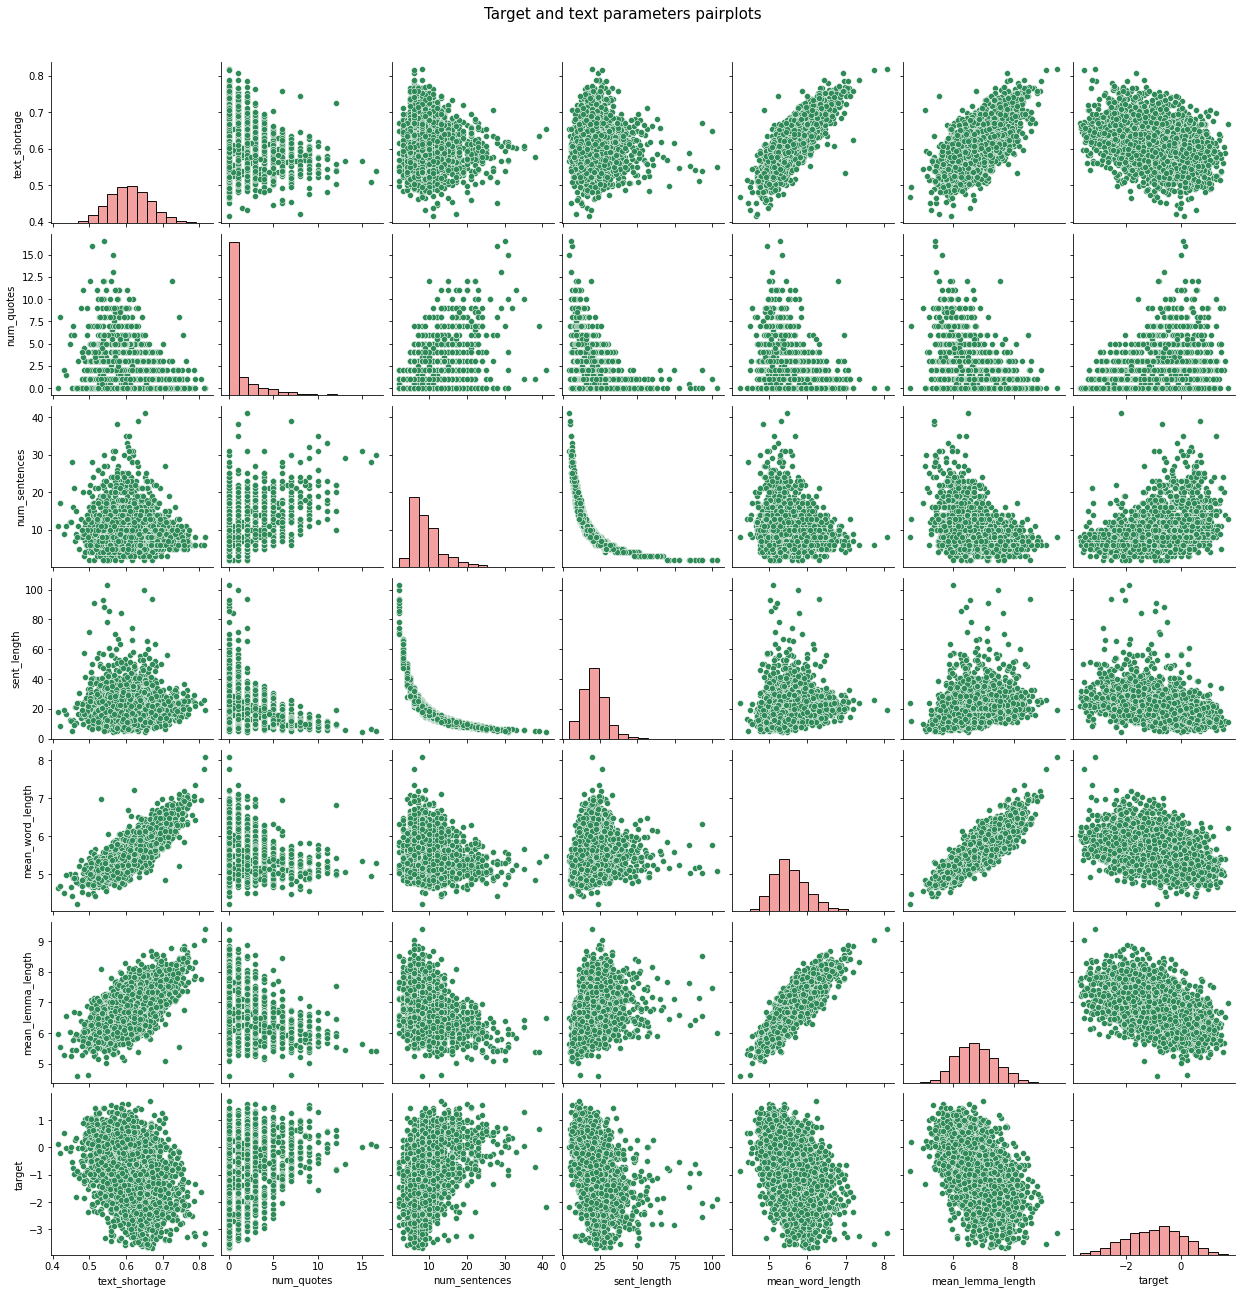

In [12]:
df = pd.concat([text_params, train["target"]], axis=1)

ax = sns.pairplot(data=df,
                  diag_kws=dict(bins=15, color="lightcoral"),
                  plot_kws=dict(color="seagreen"))
ax.fig.suptitle("Target and text parameters pairplots", fontsize=15, y=1.03)
plt.show();

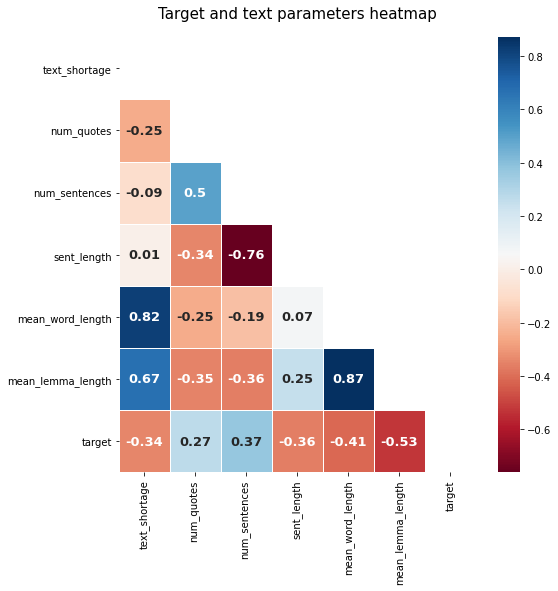

In [13]:
# Plot dataframe
corr = df.corr().round(2)

# Mask to hide upper-right part of plot as it is a duplicate
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Making a plot
plt.figure(figsize=(8,8))
ax = sns.heatmap(corr, annot=True, mask=mask, cmap="RdBu", linewidths=1,
                 annot_kws={"weight": "bold", "fontsize": 13})

ax.set_title("Target and text parameters heatmap", fontsize=15, y=1.03)
plt.show();

# **RoBERTa fine-tuning**

In [14]:
# Loading RoBERTa tokenizer and model
roberta_tokenizer = RobertaTokenizer.from_pretrained("/kaggle/input/roberta-large-model-tensorflow/")
roberta_model = TFRobertaModel.from_pretrained("/kaggle/input/roberta-large-model-tensorflow/")

Some layers from the model checkpoint at /kaggle/input/roberta-large-model-tensorflow/ were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at /kaggle/input/roberta-large-model-tensorflow/.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


In [15]:
roberta_model.summary()

Model: "tf_roberta_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
roberta (TFRobertaMainLayer) multiple                  355359744 
Total params: 355,359,744
Trainable params: 355,359,744
Non-trainable params: 0
_________________________________________________________________


In [16]:
# Calculating edges of target bins to be used for stratified split
target_bin_edges = np.histogram_bin_edges(train["target"], bins=10)
target_bin_edges[0] = -np.inf
target_bin_edges[-1] = np.inf
target_bins = pd.cut(train["target"], target_bin_edges, labels=np.arange(10))
target_bins

0       6
1       6
2       5
3       4
4       7
       ..
2829    9
2830    7
2831    7
2832    6
2833    7
Name: target, Length: 2834, dtype: category
Categories (10, int64): [0 < 1 < 2 < 3 ... 6 < 7 < 8 < 9]

In [17]:
X = train["excerpt"].copy()
y = train["target"].copy()
# Splitting data into train and valid folds using target bins for stratification
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, valid_idx in split.split(X, target_bins):
    X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
    y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]

In [18]:
def tokenize_text(text, tokenizer):
    input_ids = []
    attention_mask = []
    for row in text:
        tokenized_text = (tokenizer.encode_plus(row, truncation=True, max_length=340, padding="max_length", return_tensors='tf', return_attention_mask=True).data)
        input_ids.append(tokenized_text["input_ids"][0])
        attention_mask.append(tokenized_text["attention_mask"][0])
    return np.array(input_ids), np.array(attention_mask)

In [19]:
# tokenized_text = (roberta_tokenizer.encode_plus(X_train.iloc[0], truncation=True, max_length=340, padding="max_length", return_tensors='tf', return_attention_mask=True).data)
# tokenized_text["attention_mask"][0]

In [20]:
train_input_ids, train_attention_mask = tokenize_text(X_train, roberta_tokenizer)
valid_input_ids, valid_attention_mask = tokenize_text(X_valid, roberta_tokenizer)

In [21]:
# Forbidding training of model's layers
for layer in roberta_model.layers:
    layer.trainable = True

# Fixing random state of initialized weights to ensure results repeatability
weight_initializer = tf.keras.initializers.GlorotNormal(seed=42)

input_ids_layer = tf.keras.layers.Input(shape=(340,), 
                                        name='input_ids', 
                                        dtype='int32')
input_attention_layer = tf.keras.layers.Input(shape=(340,), 
                                              name='input_attention', 
                                              dtype='int32')

last_hidden_state = roberta_model([input_ids_layer, input_attention_layer])[0]
cls_token = last_hidden_state[:, 0, :]

output = tf.keras.layers.Dense(1, 
                               activation='linear',
                               kernel_initializer=weight_initializer,  
                               )(cls_token)

model = tf.keras.Model([input_ids_layer, input_attention_layer], output)

loss = tf.keras.losses.MeanSquaredError()

batch_size = 32
num_epochs = 4
num_train_steps = (len(X_train) // batch_size) * num_epochs
lr_scheduler = PolynomialDecay(
    initial_learning_rate=5e-5,
    end_learning_rate=0.,
    decay_steps=num_train_steps
)

opt = Adam(learning_rate=lr_scheduler)

model.compile(optimizer=opt, 
              loss=loss)

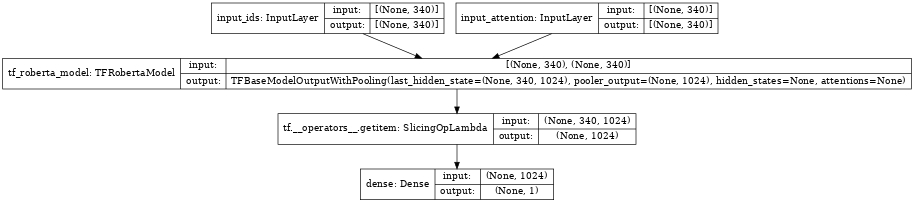

In [22]:
tf.keras.utils.plot_model(model, show_shapes=True, dpi=48)

In [23]:
%%time
model.fit(
        x=[train_input_ids, train_attention_mask],
        y=y_train.to_numpy(), 
        validation_data=([valid_input_ids, valid_attention_mask], y_valid.to_numpy()),
        batch_size=2,
        epochs=4
)

Epoch 1/4
1134/1134 [==============================] - 475s 394ms/step - loss: 2.1107 - val_loss: 0.6240
Epoch 2/4
1134/1134 [==============================] - 442s 390ms/step - loss: 0.7953 - val_loss: 0.6240
Epoch 3/4
1134/1134 [==============================] - 441s 389ms/step - loss: 0.7473 - val_loss: 0.6240
Epoch 4/4
1134/1134 [==============================] - 441s 389ms/step - loss: 0.7999 - val_loss: 0.6240
CPU times: user 21min 24s, sys: 4min 40s, total: 26min 4s
Wall time: 29min 58s


# **Data preparation**

In [24]:
def scale_train_text_params(df):
    scalers = []
#     scaled_columns = []
    
    for column in df.columns:
        scaler = MinMaxScaler()
        df[column] = scaler.fit_transform(np.array(df[column]).reshape(-1, 1))
        scalers.append(scaler)
#         scaled_columns.append(scaled_column)

    return df, scalers

def scale_test_text_params(df, scalers):
#     scaled_columns = []
    
    for i, column in enumerate(df.columns):
        scaler = scalers[i]
        df[column] = scaler.transform(np.array(df[column]).reshape(-1, 1))
#         scaled_columns.append(scaled_column)

    return df

def vectorize_text_data(X_train, text_params, roberta_tokenizer, roberta_model):
    vectors = []
    
    for i, text in enumerate(X_train):
        encoded_input = roberta_tokenizer.encode_plus(text, truncation=True, max_length=340, padding="max_length", return_tensors='tf', return_attention_mask=True)
        output = roberta_model(encoded_input)
        vectors.append(np.array(output[1])[0])
        if ((i+1) % 100) == 0:
            print(f"Vectorized {i+1} of {len(X_train)}")
    print(f"Vectorized {i+1} of {len(X_train)}")
    vectorized_text = pd.DataFrame(vectors)
    print(f"Vectorized text shape: {vectorized_text.shape}")
    
#     vectorized_text.to_csv('vectorized_text.csv', index=False)
    
    X_train = pd.concat((text_params, vectorized_text), axis=1)
    print(f"Concatenated data shape: {X_train.shape}")
    
    return X_train

In [25]:
%%time
# Scaling text parameters
text_params, scalers = scale_train_text_params(text_params)
# Vectorizing text data and concatenating it with text parameters
X = vectorize_text_data(train["excerpt"].copy(), text_params, roberta_tokenizer, roberta_model)
y = train["target"].copy()

Vectorized 100 of 2834
Vectorized 200 of 2834
Vectorized 300 of 2834
Vectorized 400 of 2834
Vectorized 500 of 2834
Vectorized 600 of 2834
Vectorized 700 of 2834
Vectorized 800 of 2834
Vectorized 900 of 2834
Vectorized 1000 of 2834
Vectorized 1100 of 2834
Vectorized 1200 of 2834
Vectorized 1300 of 2834
Vectorized 1400 of 2834
Vectorized 1500 of 2834
Vectorized 1600 of 2834
Vectorized 1700 of 2834
Vectorized 1800 of 2834
Vectorized 1900 of 2834
Vectorized 2000 of 2834
Vectorized 2100 of 2834
Vectorized 2200 of 2834
Vectorized 2300 of 2834
Vectorized 2400 of 2834
Vectorized 2500 of 2834
Vectorized 2600 of 2834
Vectorized 2700 of 2834
Vectorized 2800 of 2834
Vectorized 2834 of 2834
Vectorized text shape: (2834, 1024)
Concatenated data shape: (2834, 1030)
CPU times: user 8min 15s, sys: 0 ns, total: 8min 15s
Wall time: 8min 15s


In [26]:
X.head()

,text_shortage,num_quotes,num_sentences,sent_length,mean_word_length,mean_lemma_length,0,1,2,3,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.448382,0.000000,0.230769,0.120646,0.324457,0.393908,0.719030,0.681134,0.399395,-0.542096,...,0.626809,0.615811,0.131549,-0.796977,0.001311,-0.703637,0.831362,0.035318,0.764896,-0.182659
1,0.429156,0.363636,0.333333,0.069966,0.315896,0.391369,0.627812,0.651147,0.388390,-0.609663,...,0.573445,0.586069,0.181109,-0.799241,0.006069,-0.699465,0.850471,0.028951,0.710688,-0.205657
2,0.410101,0.303030,0.230769,0.112333,0.272143,0.347784,0.667012,0.693804,0.420903,-0.536348,...,0.590797,0.594036,0.119104,-0.788744,-0.124224,-0.724817,0.836153,0.023422,0.645001,-0.167385
3,0.534552,0.000000,0.076923,0.292822,0.314713,0.310568,0.727631,0.640328,0.347666,-0.609400,...,0.622414,0.657471,0.199941,-0.779901,-0.008587,-0.709046,0.827875,0.016347,0.705480,-0.108516
4,0.387272,0.000000,0.076923,0.260308,0.144729,0.203005,0.654965,0.636686,0.423755,-0.554064,...,0.670829,0.576062,0.171561,-0.799204,0.009371,-0.726399,0.828039,0.018932,0.719593,-0.225589


# **Optuna**

In [27]:
def train_model_optuna(trial, X_train, X_valid, y_train, y_valid):
    """
    A function to train a model using different hyperparamerters combinations provided by Optuna. 
    RMSE of validation data predictions is returned to estimate hyperparameters effectiveness.
    """
    preds = 0
    
       
    #A set of hyperparameters to optimize by optuna
    lgbm_params = {
        'objective': trial.suggest_categorical('objective', ['regression']),
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt']),
        'num_leaves': trial.suggest_int('num_leaves', 2, 31),
        'max_depth': trial.suggest_int('max_depth', 1, 30),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'n_estimators': trial.suggest_categorical('n_estimators', [1000]),        
        'reg_alpha': trial.suggest_float('reg_alpha', 1.0, 20.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.00001, 0.1),
        'random_state': trial.suggest_categorical('random_state', [42]), 
        'n_jobs': trial.suggest_categorical('n_jobs', [4]), 

    }

    # Model loading and training
    model = LGBMRegressor(**lgbm_params)
    model.fit(X_train, y_train,
              eval_set=[(X_valid, y_valid)],
              eval_metric="rmse",
              early_stopping_rounds=100,
              verbose=False)
    
    # Out of fold predictions
    oof = model.predict(X_valid)
    # Number of actually grown trees before overfitting is detected 
    print(f"Number of boosting rounds: {model.best_iteration}")
    
    return np.sqrt(mean_squared_error(y_valid, oof))

The code below runs hyperparameters optimization. It is commeted to save runtime.

In [28]:
# %%time
# # Splitting data into train and valid folds using target bins for stratification
# split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# for train_idx, valid_idx in split.split(X, target_bins):
#     X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
#     y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]
# # Setting optuna verbosity to show only warning messages
# # If the line is uncommeted each iteration results will be shown
# # optuna.logging.set_verbosity(optuna.logging.WARNING)

# study = optuna.create_study(direction='minimize')
# study.optimize(lambda trial: train_model_optuna(trial, X_train, X_valid,
#                                                     y_train, y_valid),
#                n_trials = 5)

# # Showing optimization results
# print('Number of finished trials:', len(study.trials))
# print('Best trial parameters:', study.best_trial.params)
# print('Best score:', study.best_value)

# **LGBMRegressor model training**

In [29]:
# The function splits given train data into 10 folds and trains each model on each fold.
# Each model makes test predictions. Mean predictions are returned. 
def train_with_folds(X, y, X_test, target_bins, params):
    splits = 10
    skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)
    oof_preds = np.zeros((X.shape[0],))
    model_preds = 0
    model_fi = 0
    for num, (train_idx, valid_idx) in enumerate(skf.split(X, target_bins)):
        X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
        y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]
        model = LGBMRegressor(**params)
        model.fit(X_train, y_train,
                  eval_set=[(X_valid, y_valid)],
                  eval_metric="rmse",
                  early_stopping_rounds=100,
                  verbose=False)
        model_preds += model.predict(X_test) / splits
        model_fi += model.feature_importances_
        oof_preds[valid_idx] = model.predict(X_valid)
        print(f"Fold {num} RMSE: {np.sqrt(mean_squared_error(y_valid, oof_preds[valid_idx]))}")
    model_rmsle = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"Overall RMSE: {model_rmsle}")
    
    return model_preds, model_fi

In [30]:
# Hyperparameters values optimized by Optuna
lgbm_params = {'objective': 'regression',
               'boosting_type': 'gbdt',
               'num_leaves': 13,
               'max_depth': 6,
               'learning_rate': 0.11136686062332299,
               'n_estimators': 3000,
               'reg_alpha': 2.129407050814302,
               'reg_lambda': 0.05088230910987312,
               'random_state': 42,
               'n_jobs': 4}

In [31]:
# Preprocessing test data
text_params = get_text_data_parameters(test["excerpt"], stop_words)
text_params = scale_test_text_params(text_params, scalers)
X_test = vectorize_text_data(test["excerpt"], text_params, roberta_tokenizer, roberta_model)

Vectorized 7 of 7
Vectorized text shape: (7, 1024)
Concatenated data shape: (7, 1030)


In [32]:
%%time
preds, feature_importances = train_with_folds(X, y, X_test, target_bins, lgbm_params)

Fold 0 RMSE: 0.6098750236746602
Fold 1 RMSE: 0.6047851790351108
Fold 2 RMSE: 0.6449948682340919
Fold 3 RMSE: 0.5884454356986419
Fold 4 RMSE: 0.6548747313978787
Fold 5 RMSE: 0.6220284205068616
Fold 6 RMSE: 0.613103746145924
Fold 7 RMSE: 0.5995738277811153
Fold 8 RMSE: 0.6516305336157472
Fold 9 RMSE: 0.6366048635452034
Overall RMSE: 0.6229660862396333
CPU times: user 5min 9s, sys: 2.43 s, total: 5min 11s
Wall time: 2min 52s


Let's check feature importances of all features and then engineered feature only.

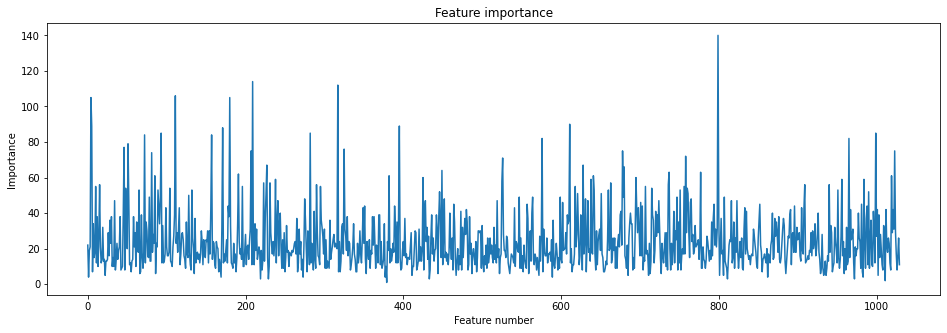

In [33]:
fig, ax = plt.subplots(figsize=(16, 5))
ax = sns.lineplot(data=pd.Series(feature_importances))
ax.set_title("Feature importance")
ax.set_xlabel("Feature number")
ax.set_ylabel("Importance")
plt.show();

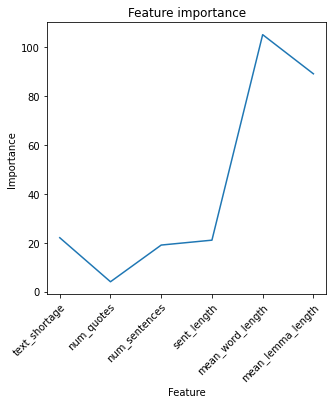

In [34]:
fig, ax = plt.subplots(figsize=(5, 5))
ax = sns.lineplot(x=text_params.columns, y=pd.Series(feature_importances[:6]))
ax.set_title("Feature importance")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.show();

# **Submission**

In [35]:
submission = pd.read_csv("/kaggle/input/commonlitreadabilityprize/sample_submission.csv", low_memory=False)
submission["target"] = preds
submission.to_csv('submission.csv', index=False)
submission

,id,target
0,c0f722661,-0.685317
1,f0953f0a5,-0.170768
2,0df072751,-0.682713
3,04caf4e0c,-2.154818
4,0e63f8bea,-1.935168
5,12537fe78,-0.681238
6,965e592c0,0.556105
